In [138]:
import shutil

import pandas as pd
import ast
import numpy as np
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import AutoTokenizer, AutoModel, BertModel
import torch
from torch.utils.data import Dataset, DataLoader

from augmentation_functions import ensure_min_per_label
from augmentation_functions import augment_minority_data, augment_whole_dataset , parse_list

### Preprocessing the dataset (augmentation, splitting, tokenizing)

In [139]:
# Constants for data paths, model names and hyperparameters
DATA_PATH = 'OLD_final_dataset.csv'
TEXT_COLUMN = 'tool_description'
LABEL_COLUMN = 'tool_category'
PRETRAINED_MODEL_NAME = 'bert-base-uncased'
MAX_SEQ_LENGTH = 128  # Maximum token length for BERT inputs
BATCH_SIZE = 32       # Batch size for training
TEST_SIZE = 0.2      # Fraction of data reserved for testing
VAL_SIZE = 0.2     # Fraction of remaining data reserved for validation

In [140]:

data = pd.read_csv(DATA_PATH)

data[LABEL_COLUMN] = data[LABEL_COLUMN].apply(parse_list)


In [141]:
np.random.seed(42)

#### Mulit-Hot-Encode labels

In [142]:
X  = data.drop(columns=[LABEL_COLUMN]).to_numpy()
mlb_strat = MultiLabelBinarizer()
Y  = mlb_strat.fit_transform(data[LABEL_COLUMN])

#### Split into train, test , val data

In [143]:
X_trainval, y_trainval, X_test, y_test = iterative_train_test_split(
        X, Y, test_size=TEST_SIZE)


In [144]:
X_train, y_train, X_val, y_val = iterative_train_test_split(
        X_trainval, y_trainval, test_size=VAL_SIZE)

#### Make sure each split contains each category at least once

In [145]:
# Y is a (n_rows × n_labels) NumPy array or sparse matrix
test_label_counts = y_test.sum(axis=0)                # 1-D array of counts
test_label_counts = pd.Series(test_label_counts, index=mlb_strat.classes_)
zero_in_test = (test_label_counts == 0).sum()
print(zero_in_test)

7


In [146]:
# Y is a (n_rows × n_labels) NumPy array or sparse matrix
train_label_counts = y_train.sum(axis=0)                # 1-D array of counts
train_label_counts = pd.Series(train_label_counts, index=mlb_strat.classes_)
zero_in_train = (train_label_counts == 0).sum()
print(zero_in_train)

1


In [147]:
val_label_counts = y_val.sum(axis=0)                # 1-D array of counts
val_label_counts = pd.Series(val_label_counts, index=mlb_strat.classes_)
zero_in_val = (val_label_counts == 0).sum()
print(zero_in_val)

9


In [148]:
cols = data.drop(columns=[LABEL_COLUMN]).columns
train_df = pd.DataFrame(X_train, columns=cols)
train_df[LABEL_COLUMN] = mlb_strat.inverse_transform(y_train)

val_df = pd.DataFrame(X_val, columns=cols)
val_df[LABEL_COLUMN] = mlb_strat.inverse_transform(y_val)

test_df = pd.DataFrame(X_test, columns=cols)
test_df[LABEL_COLUMN] = mlb_strat.inverse_transform(y_test)

In [149]:
len(train_df)

86

In [150]:
train_df = augment_minority_data(train_df,TEXT_COLUMN,LABEL_COLUMN)

In [151]:
len(train_df)

1063

In [152]:
data_exploded = train_df.explode("tool_category")  # one category per row

category_counts = data_exploded["tool_category"].value_counts()

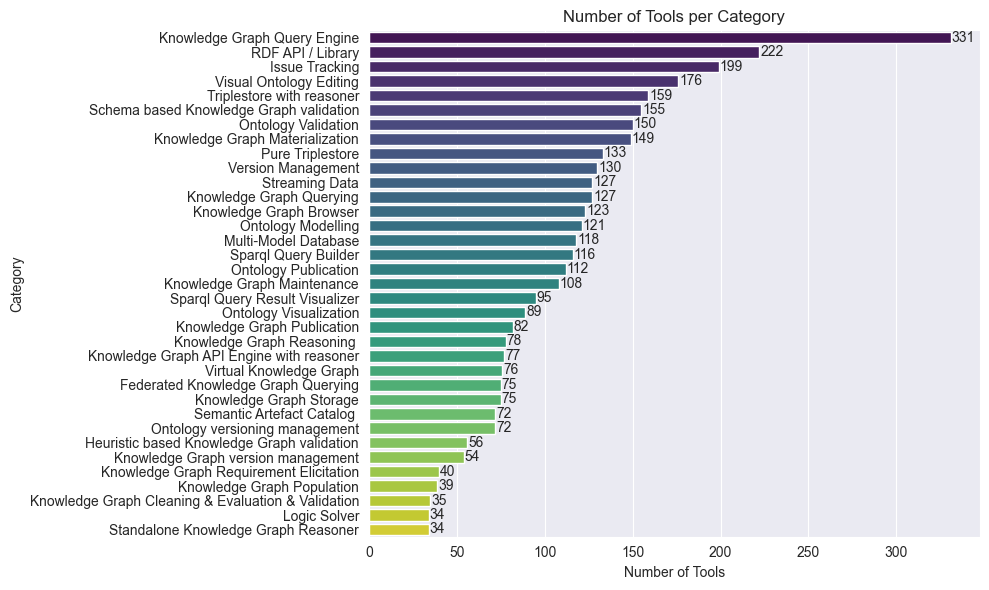

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.barplot(y=category_counts.index, x=category_counts.values, palette="viridis" , hue = category_counts.index)


plt.title("Number of Tools per Category")
plt.xlabel("Number of Tools")
plt.ylabel("Category")

for i, v in enumerate(category_counts.values):
    ax.text(v + 0.5, i, str(v), va='center')


plt.tight_layout()
plt.show()

In [154]:
mlb = MultiLabelBinarizer()
mlb.fit(train_df[LABEL_COLUMN])
for split_df in (train_df, val_df, test_df):
    split_df['labels_enc'] = mlb.transform(split_df[LABEL_COLUMN]).tolist()

/Users/finnseemann/Documents/Studium/Bachelor_Thesis/Semantic_Toolhub_Pipeline/venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Numeric Ontology Analysis'] will be ignored
  warnings.warn(
/Users/finnseemann/Documents/Studium/Bachelor_Thesis/Semantic_Toolhub_Pipeline/venv/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Numeric Ontology Analysis'] will be ignored
  warnings.warn(


In [155]:
tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)

In [156]:
def tokenize_text(text):
    return tokenizer(
        text,
        padding='max_length',
        add_special_tokens=True,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        return_tensors='pt'
    )

In [157]:
class MultiLabelTextDataset(Dataset):
    def __init__(self, df):
        self.texts = df[TEXT_COLUMN].tolist()
        self.labels = df['labels_enc'].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tok = tokenize_text(self.texts[idx])
        return {
            'input_ids': tok['input_ids'].squeeze(),
            'attention_mask': tok['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [158]:
train_loader = DataLoader(MultiLabelTextDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(MultiLabelTextDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(MultiLabelTextDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

In [159]:
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Distinct labels: {len(mlb.classes_)}")

Train: 1063, Val: 19, Test: 27
Distinct labels: 35


### Model Training

In [174]:
from transformers import BertModel
from torch import nn

In [179]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
LR = 3e-5
NUM_EPOCHS = 10

In [181]:
def load_checkpoint(checkpoint_path, model, optimizer):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    valid_loss_min = checkpoint["valid_loss_min"]
    return model, optimizer, checkpoint["epoch"], valid_loss_min.item()

def save_checkpoint(state, is_best, checkpoint_path, best_model_path):
    f_path = checkpoint_path
    torch.save(state, f_path)
    if is_best:
        best_fpath = best_model_path
        shutil.copyfile(f_path, best_fpath)

In [176]:
class BERT_Class(nn.Module):
    def __init__(self):
        super(BERT_Class, self).__init__()
        self.bert_model = BertModel.from_pretrained("bert-base-uncased" , return_dict=True)
        self.dropout = nn.Dropout(0.3)
        self.linear = nn.Linear(768,36)

    def forward(self , input_ids, attention_mask, token_type_ids):
        output = self.bert_model(input_ids, attention_mask, token_type_ids)
        output_dropout = self.dropout(output.pooler_output)
        output = self.linear(output_dropout)

In [ ]:
model = BERT_Class()
model.to(DEVICE)

In [178]:
def loss_func(outputs, targets):
    return nn.BCEWithLogitsLoss()(outputs, targets)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [183]:
def train_model(
        n_epochs,
        train_dataloader,
        val_dataloader,
        model,
        optimizer,
        checkpoint_path,
        best_model_path
):
    valid_loss_min = np.inf

    for epoch in range(1, n_epochs+1):
        train_loss = 0
        val_loss = 0
        model.train()

        # training loop

        for index, batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
            input_ids = batch["input_ids"].to(DEVICE, dtype=torch.long)
            attention_mask = batch["attention_mask"].to(DEVICE, dtype=torch.long)
            token_type_ids = batch["token_type_ids"].to(DEVICE, dtype=torch.long)

            targets = batch["targets"].to(DEVICE, dtype=torch.float)
            outputs = model(input_ids, attention_mask, token_type_ids)

            optimizer.zero_grad()
            loss = loss_func(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss = train_loss + (1/(index+1)) * (loss.item() - train_loss)

            # validation loop

        model.eval()
        with torch.no_grad():
            for index, batch in enumerate(val_dataloader):
                input_ids = batch["input_ids"].to(DEVICE, dtype=torch.long)
                attention_mask = batch["attention_mask"].to(DEVICE, dtype=torch.long)
                token_type_ids = batch["token_type_ids"].to(DEVICE, dtype=torch.long)

                targets = batch["targets"].to(DEVICE, dtype=torch.float)
                outputs = model(input_ids, attention_mask, token_type_ids)

                loss = loss_func(outputs, targets)
                val_loss = val_loss + (1/(index+1)) * (loss.item() - val_loss)


        checkpoint = {
            'epoch': epoch+1,
            'valid_loss_min': val_loss,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict()
        }

        save_checkpoint(checkpoint, False, checkpoint_path, best_model_path)

    return model


In [ ]:
trained_model = train_model(NUM_EPOCHS, train_loader, val_loader, model, optimizer, "/current_checkpoint", "/best_model.pt")

In [160]:
import os
from transformers import (
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
    AutoTokenizer
)
from torch.optim import AdamW
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm.auto import tqdm

In [161]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
PRETRAINED_MODEL_NAME = 'bert-base-uncased'
NUM_LABELS = len(mlb.classes_)
MAX_SEQ_LENGTH = MAX_SEQ_LENGTH
BATCH_SIZE = 16                 # fixed batch size
NUM_EPOCHS = 10                  # fixed number of epochs
LR = 3e-5                       # fixed learning rate
WEIGHT_DECAY = 0.01             # fixed weight decay              # no warmup
OUTPUT_DIR = 'semanticbert_multilabel_model'
early_stopping_patience = 2

In [162]:
model = BertForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
).to(DEVICE)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [163]:
optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [164]:
total_steps = len(train_loader) * NUM_EPOCHS

num_warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

In [165]:
def evaluate_model(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            inputs = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**inputs)
            all_logits.append(outputs.logits.cpu().numpy())
            all_labels.append(inputs['labels'].cpu().numpy())
    logits = np.vstack(all_logits)
    true = np.vstack(all_labels)
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.3).astype(int)

    f1 = f1_score(true, preds, average='micro')
    prec = precision_score(true, preds, average='micro')
    rec = recall_score(true, preds, average='micro')

    return f1, prec, rec

In [166]:
best_val_f1 = 0.0
epochs_no_improve = 0

for epoch in range(1 , NUM_EPOCHS+1):
    model.train()
    total_loss = 0.0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        optimizer.zero_grad()
        inputs = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**inputs)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # Validation phase
    val_f1 , val_prec , val_rec = evaluate_model(model, val_loader)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS},"
        f" | Train Loss: {avg_train_loss:.4f}"
        f" | Val F1: {val_f1:.4f}"
        f" | Val Prec: {val_prec:.4f}"
        f" | Val Rec: {val_rec:.4f}"
    )

    # Early Stopping
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        model.save_pretrained(OUTPUT_DIR)
        print(f"New best model saved with Val F1: {best_val_f1:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print(f"No improvement in {early_stopping_patience} epochs. Stopping early.")
            break


Epoch 2/10: 100%|██████████| 34/34 [02:08<00:00,  3.78s/it]


Epoch 1/10, | Train Loss: 0.6095 | Val F1: 0.1752 | Val Prec: 0.0973 | Val Rec: 0.8846
New best model saved with Val F1: 0.1752


Epoch 3/10: 100%|██████████| 34/34 [02:11<00:00,  3.85s/it]


Epoch 2/10, | Train Loss: 0.3995 | Val F1: 0.2647 | Val Prec: 0.5625 | Val Rec: 0.1731
New best model saved with Val F1: 0.2647


Epoch 4/10: 100%|██████████| 34/34 [02:17<00:00,  4.06s/it]


Epoch 3/10, | Train Loss: 0.3304 | Val F1: 0.2540 | Val Prec: 0.7273 | Val Rec: 0.1538


Epoch 5/10: 100%|██████████| 34/34 [02:23<00:00,  4.21s/it]


Epoch 4/10, | Train Loss: 0.3005 | Val F1: 0.1724 | Val Prec: 0.8333 | Val Rec: 0.0962
No improvement in 2 epochs. Stopping early.


In [168]:
test_f1, test_prec, test_rec = evaluate_model(model, test_loader)
print(f"Test F1: {test_f1:.4f}")

Test F1: 0.1795


In [169]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

('semanticbert_multilabel_model/tokenizer_config.json',
 'semanticbert_multilabel_model/special_tokens_map.json',
 'semanticbert_multilabel_model/vocab.txt',
 'semanticbert_multilabel_model/added_tokens.json',
 'semanticbert_multilabel_model/tokenizer.json')